In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# EDA


In [2]:
df = pd.read_csv('Student_performance_data.csv')

In [3]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [4]:
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [6]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


<Axes: xlabel='GPA', ylabel='Count'>

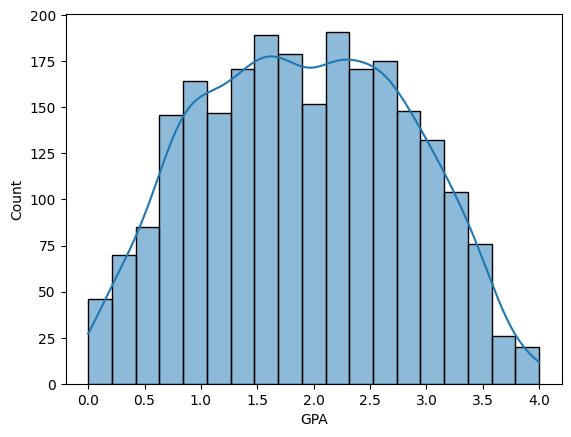

In [7]:
sns.histplot(x = 'GPA', data = df, kde=True)

<Axes: ylabel='GPA'>

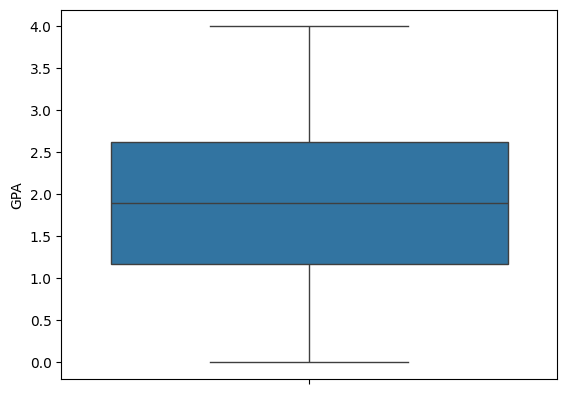

In [8]:
sns.boxplot(df['GPA'])

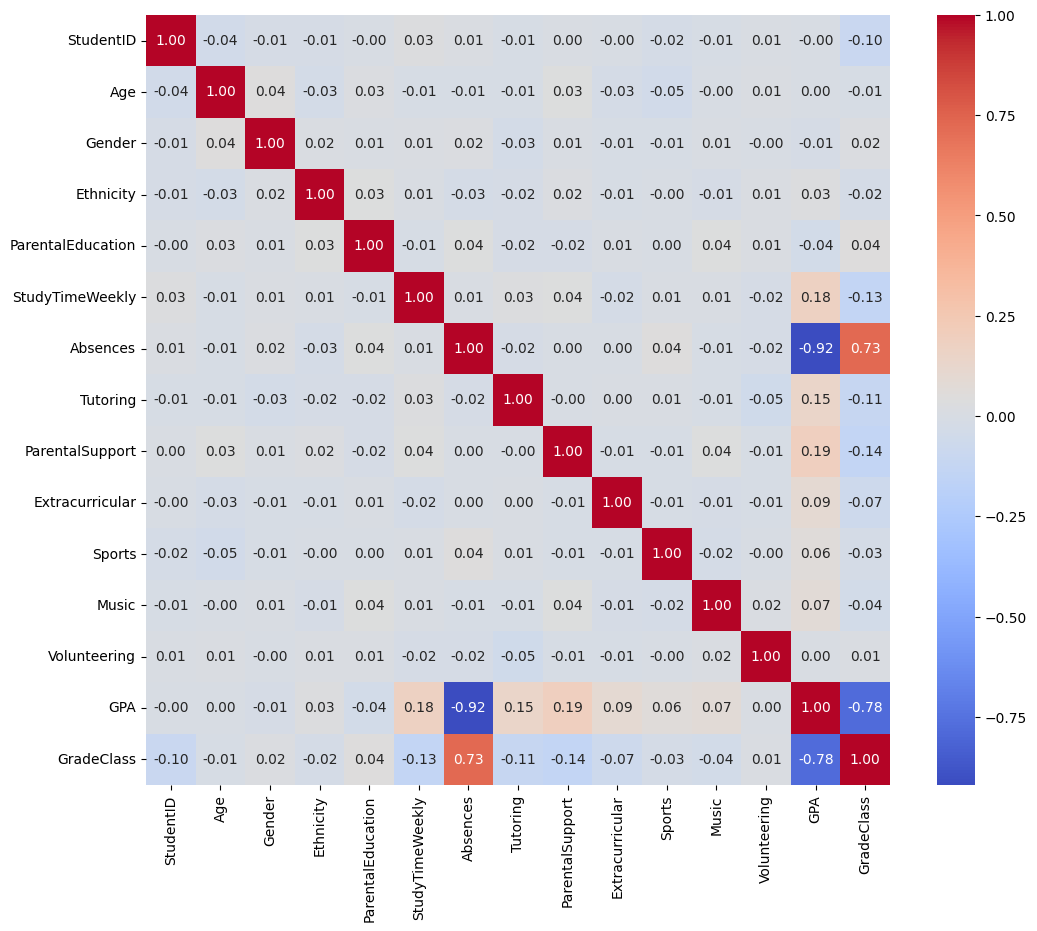

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [10]:
# Dependent and Independent Variables Seprate
# Train test and Split
# Standerd Scaler
# Training Testing

In [11]:
X =  df.drop(['StudentID', 'GPA'], axis = 1)
y = df['GPA']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42)

In [14]:
df.shape

(2392, 15)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train.shape

(1674, 13)

In [18]:
X_test.shape

(718, 13)

In [19]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)

In [20]:
model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [21]:
y_pred = model.predict(X_test)

In [22]:
# y_pred

# Evaluate

In [23]:
from sklearn.metrics import r2_score

# Evaluate on testing data


In [24]:
r2 = r2_score(y_test, y_pred)

In [25]:
r2

0.818006764492333

# now we evaluate on trainign data

In [26]:
y_pred_train = model.predict(X_train)

In [27]:
r2_score(y_train, y_pred_train)

0.8539354150936007

# Now evaluate on adjusted r2_score



In [28]:
n = X_test.shape[0]  # Number of observations in the testing set
p = X_test.shape[1]  # Number of independent variables

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted R2 Score on Testing Data: {adjusted_r2:.4f}")

Adjusted R2 Score on Testing Data: 0.8146


In [29]:
n = X_train.shape[0]  # Number of observations in the testing set
p = X_train.shape[1]  # Number of independent variables

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted R2 Score on Testing Data: {adjusted_r2:.4f}")

Adjusted R2 Score on Testing Data: 0.8166


In [30]:
r2 = []
for i in range(1, 16):
  knn_model = KNeighborsRegressor(n_neighbors=i)
  knn_model.fit(X_train, y_train)
  y_pred = knn_model.predict(X_test)
  accuracy = r2_score(y_test, y_pred)
  r2.append(accuracy)
print(r2)

[0.6684928382885009, 0.7602079875966753, 0.7887771735525688, 0.7964667378245397, 0.806570969714663, 0.806885788820126, 0.8116162897130306, 0.8142146087117791, 0.8162217078517414, 0.818006764492333, 0.8174905425459913, 0.8167462091323868, 0.815854129228945, 0.8169361356446493, 0.8183544129173128]


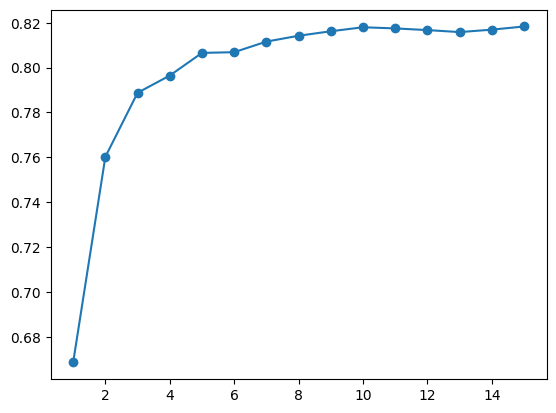

In [31]:
plt.plot(range(1, 16), r2, marker = "o")

In [32]:
# Splitting X and y for Naive Bays
# Training on raice bayes model

In [33]:
x = df.drop(['StudentID', "GradeClass"], axis = 1)
y = df['GradeClass']

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

In [38]:
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.naive_bayes import GaussianNB

In [40]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
y_pred_nb = nb_model.predict(X_test)

In [43]:
accuracy_score(y_test, y_pred_nb)

0.7674094707520891

In [44]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         0.0       0.25      0.06      0.10        33
         1.0       0.61      0.54      0.57        80
         2.0       0.63      0.80      0.71       121
         3.0       0.62      0.69      0.65       127
         4.0       0.93      0.90      0.92       357

    accuracy                           0.77       718
   macro avg       0.61      0.60      0.59       718
weighted avg       0.76      0.77      0.76       718



In [45]:
confusion_matrix(y_test, y_pred_nb)

array([[  2,  19,   4,   4,   4],
       [  6,  43,  24,   2,   5],
       [  0,   4,  97,  15,   5],
       [  0,   2,  28,  88,   9],
       [  0,   2,   0,  34, 321]])

In [46]:
y_pred_train = nb_model.predict(X_train)

In [47]:
accuracy_score(y_train, y_pred_train)

0.7921146953405018

In [48]:
import joblib


joblib.dump(model, "knn_regression.pkl")
joblib.dump(nb_model, "gaussian_nb.pkl")

['gaussian_nb.pkl']

In [49]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']